# Time Series Forecasting with Temporal Fusion Transformers (TFT)

In [ ]:
! pip install -q darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.0/340.0 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 120.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error
from darts.timeseries import TimeSeries
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.dataprocessing.transformers import Scaler
from darts.models import RNNModel
from darts.models import TFTModel
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Time Series Analysis/Python - Time Series Forecasting/Deep Learning for Time Series Forecasting /TFT/electricity.csv',
                index_col='ds',parse_dates=True)
df.head()

,unique_id,y,Exogenous1,Exogenous2
ds,,,,
2016-10-22 00:00:00,BE,70.00,49593.0,57253.0
2016-10-22 01:00:00,BE,37.10,46073.0,51887.0
2016-10-22 02:00:00,BE,37.10,44927.0,51896.0
2016-10-22 03:00:00,BE,44.75,44483.0,48428.0
2016-10-22 04:00:00,BE,37.10,44338.0,46721.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8400 entries, 2016-10-22 00:00:00 to 2018-12-23 23:00:00
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unique_id   8400 non-null   object 
 1   y           8400 non-null   float64
 2   Exogenous1  8400 non-null   float64
 3   Exogenous2  8400 non-null   float64
dtypes: float64(3), object(1)
memory usage: 328.1+ KB


## EDA

Look at electricity pricing plots for each country.

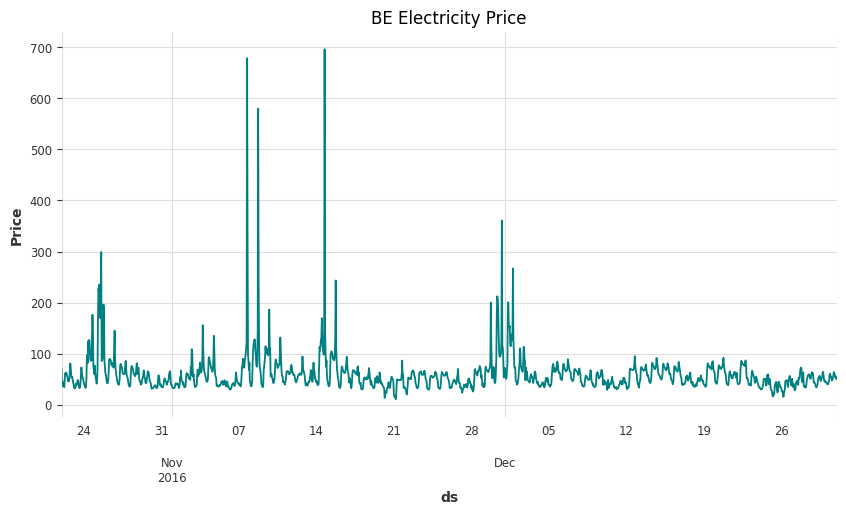

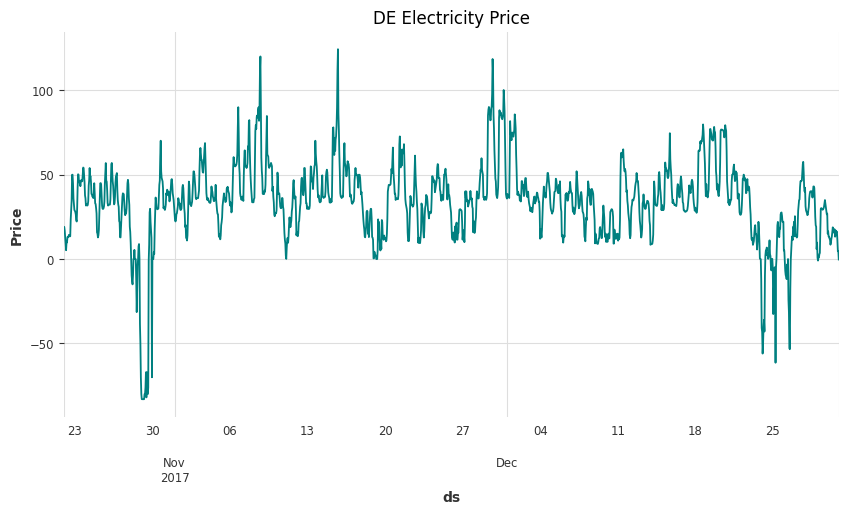

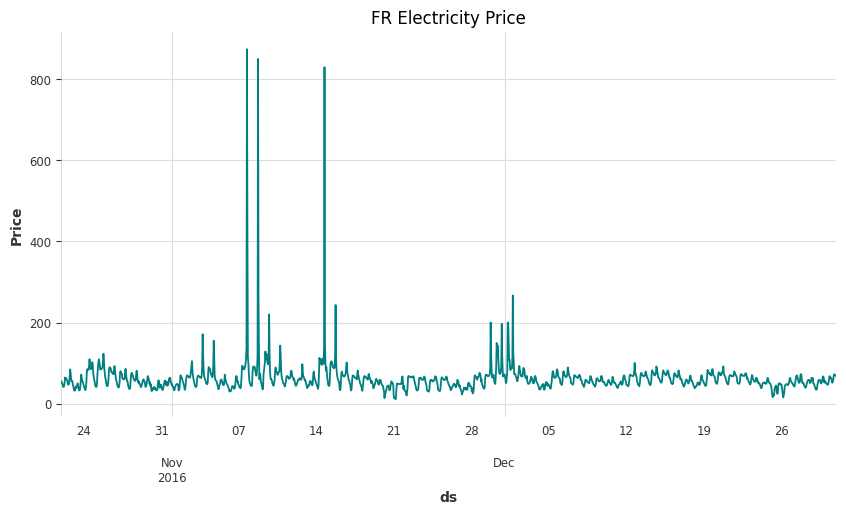

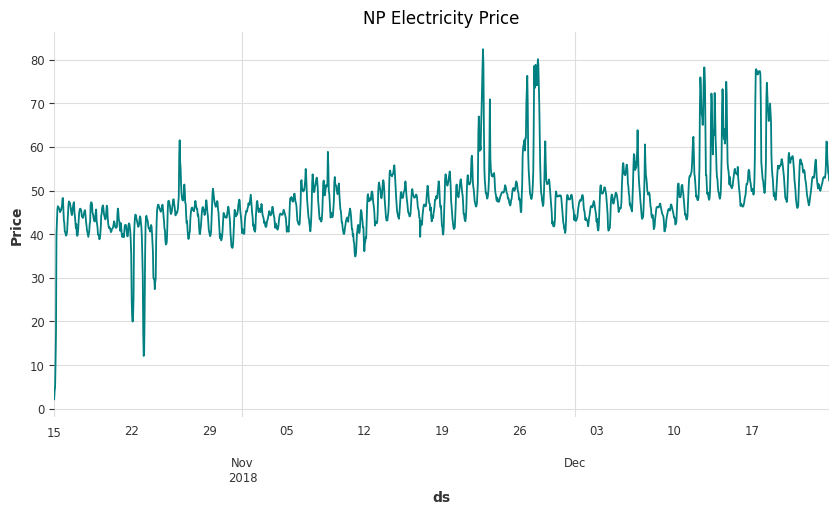

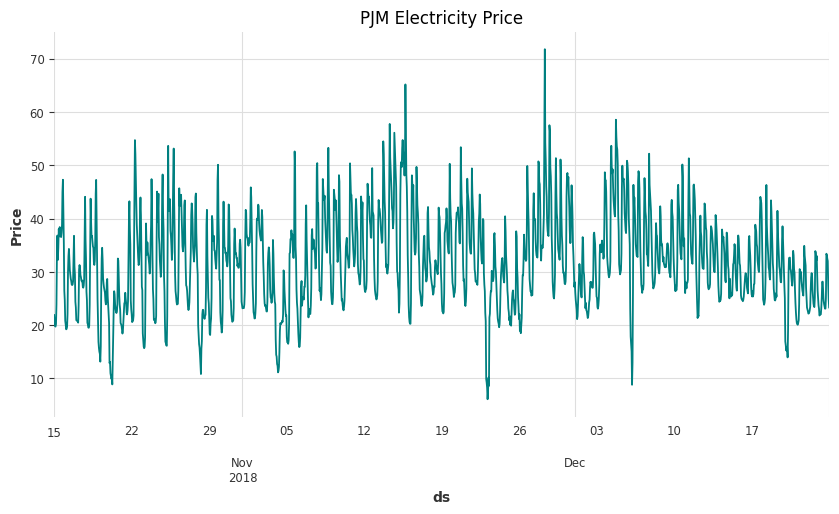

In [ ]:
for country in df.unique_id.unique():
  plt.figure(figsize=(10,5))
  df[df['unique_id']==country].y.plot(title=f'{country} Electricity Price', color='teal')
  plt.ylabel('Price')
  plt.show()


Subset df for only 'DE'

In [ ]:
df = df[df['unique_id']=='DE']
df = df.asfreq('H')
df.head()

,unique_id,y,Exogenous1,Exogenous2
ds,,,,
2017-10-22 00:00:00,DE,19.10,587.25,16972.75
2017-10-22 01:00:00,DE,19.03,623.00,16254.50
2017-10-22 02:00:00,DE,16.90,650.00,15940.25
2017-10-22 03:00:00,DE,12.98,687.25,15959.50
2017-10-22 04:00:00,DE,9.24,717.25,16071.50


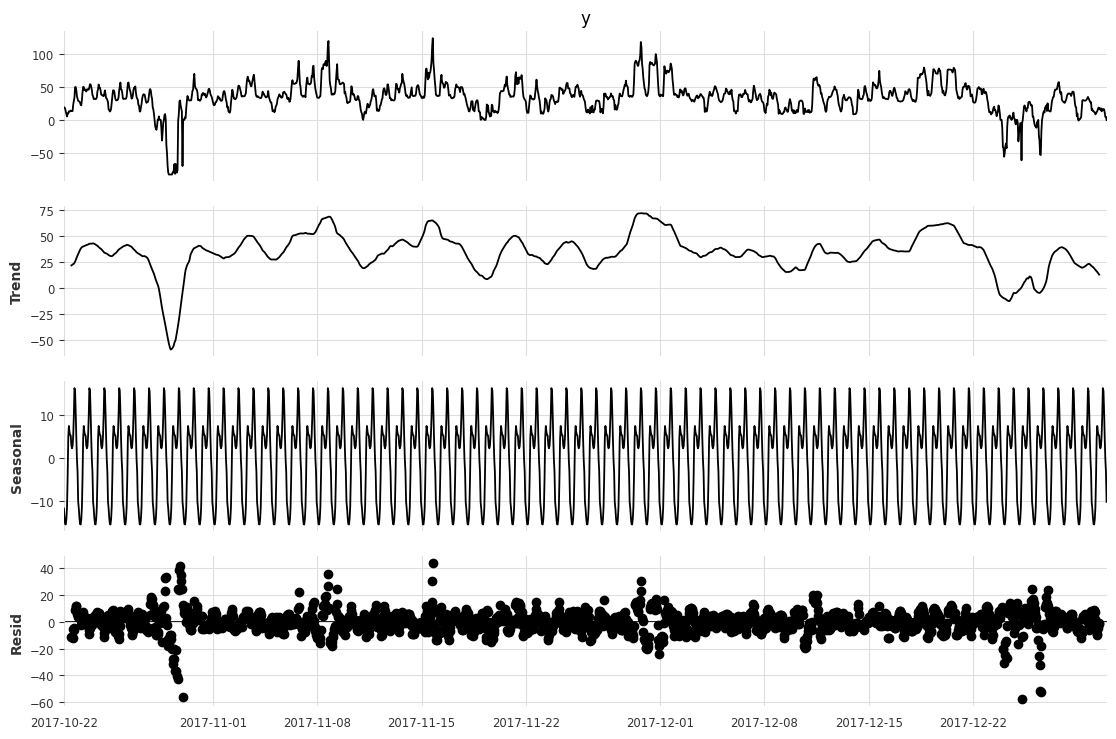

In [ ]:
# Seasonal Decomposition

# Seasonal decomposition of 'Electricity Pricing'  (24 hour period, model='additive')
result = seasonal_decompose(df['y'], model='additive', period=24)
fig = result.plot()
fig.set_figheight(8)
fig.set_figwidth(12)
plt.show()

## ACF and PACF

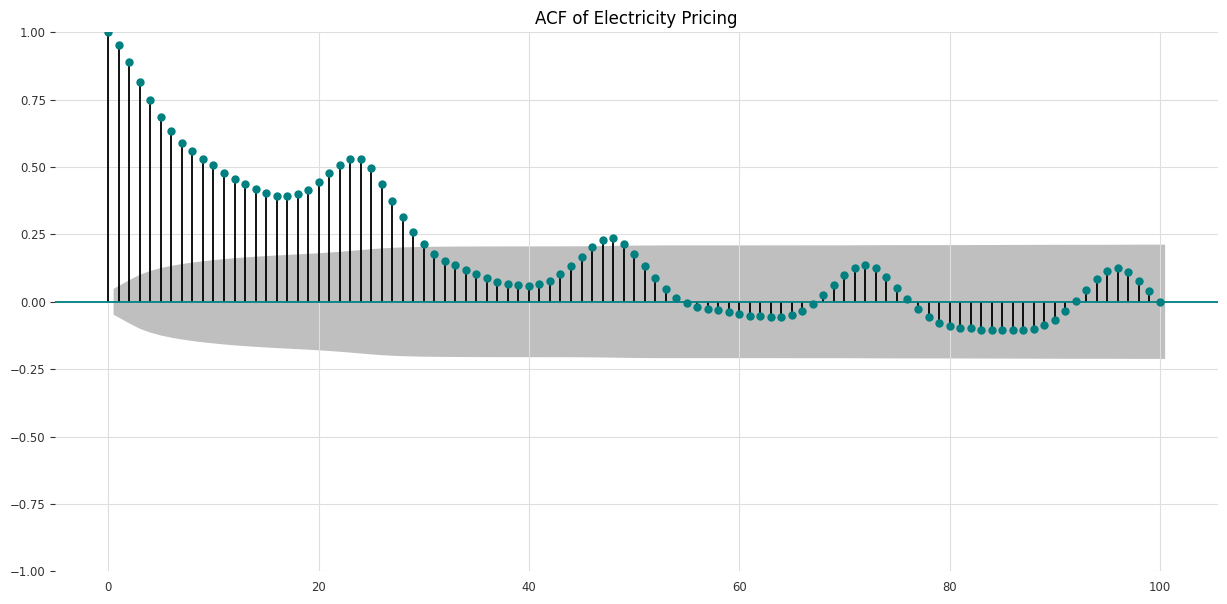

In [ ]:
# Plot the ACF for the electricity pricing data
fig, ax = plt.subplots(figsize=(15,7))
plot_acf(df['y'], lags=100, ax=ax, color='teal')
plt.title('ACF of Electricity Pricing')
plt.show()

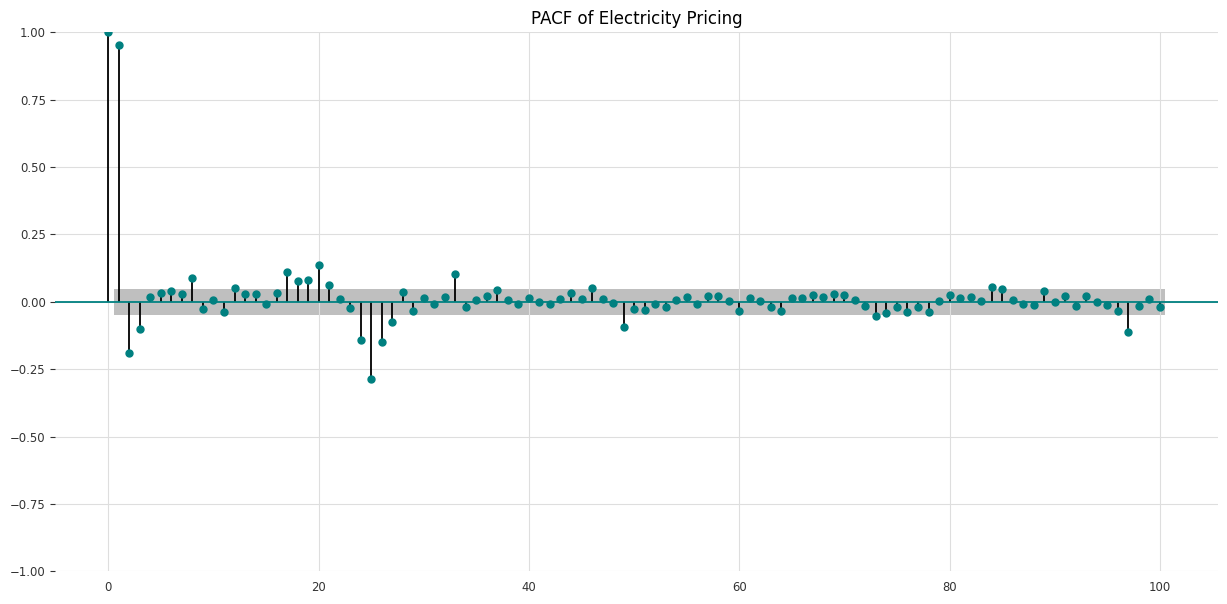

In [ ]:
# Plot the PACF for the electricity pricing data
fig, ax = plt.subplots(figsize=(15,7))
plot_pacf(df['y'], lags=100, ax=ax, color='teal')
plt.title('PACF of Electricity Pricing')
plt.show()

## Stationarity

In [ ]:
def adf_test(series, title=None):

  # Run the ADF test
  result = adfuller(series.dropna(), autolag='AIC')

  # Extract and print results
  print('ADF Statistic:', result[0])
  print('p-value:', result[1])
  print('Critical Values:')
  for key, value in result[4].items():
      print(f'   {key}: {value}')

  # Interpretation
  if result[1] < 0.05:
      print("Result: The series is likely stationary (reject H0).")
  else:
      print("Result: The series is likely non-stationary (fail to reject H0).")

In [ ]:
adf_test(df['y'])

ADF Statistic: -5.6388924926563675
p-value: 1.047547731049712e-06
Critical Values:
   1%: -3.4343097809950986
   5%: -2.8632890172254655
   10%: -2.5677011356149544
Result: The series is likely stationary (reject H0).


## Time Series, Time, Static Variables

In [ ]:
# Prepare the times-series object

series = TimeSeries.from_dataframe(df,
                                   value_cols = 'y'
                                   # static_covariates=,
                                   )
series

<TimeSeries (ds: 1680, component: 1, sample: 1)> Size: 13kB
array([[[19.1 ]],

       [[19.03]],

       [[16.9 ]],

       ...,

       [[ 4.62]],

       [[ 4.71]],

       [[-0.27]]])
Coordinates:
  * ds         (ds) datetime64[ns] 13kB 2017-10-22 ... 2017-12-30T23:00:00
  * component  (component) object 8B 'y'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

In [ ]:
# Time as an Encoder - the idea is to convert 'Year' to a small value for further processing

def encode_year(idx):
  return (idx.year-2000)/50  # 2000 and 50 are arbitrarily-chosen numbers

In [ ]:
# An example

idx = '2017-10-22 02:00:00'
encode_year(pd.to_datetime(idx))

0.34

In [ ]:
# Set up the 'add_encoders' dictionary

add_encoders = {
    'cyclic': {'future': ['hour','day','dayofweek','week','month']},
    'datetime_attribute': {'future': ['hour','day','dayofweek','week','month']},
    'position': {'past': ['relative'], 'future': ['relative']},
    'custom' : {'past': [encode_year], 'future': [encode_year]},
    'transformer': Scaler(),
    'tz': 'CET'
    }


## Past Covariates

In [ ]:
# Isolate the past covariates

X_past = df.iloc[:,2:]
X_past.head()

,Exogenous1,Exogenous2
ds,,
2017-10-22 00:00:00,587.25,16972.75
2017-10-22 01:00:00,623.00,16254.50
2017-10-22 02:00:00,650.00,15940.25
2017-10-22 03:00:00,687.25,15959.50
2017-10-22 04:00:00,717.25,16071.50


In [ ]:
X_past.tail()

,Exogenous1,Exogenous2
ds,,
2017-12-30 19:00:00,1519.50,19326.00
2017-12-30 20:00:00,1526.75,18135.25
2017-12-30 21:00:00,1514.75,17631.50
2017-12-30 22:00:00,1484.75,17553.75
2017-12-30 23:00:00,1440.75,16754.50


In [ ]:
past_covariates = TimeSeries.from_dataframe(X_past)
past_covariates

<TimeSeries (ds: 1680, component: 2, sample: 1)> Size: 27kB
array([[[  587.25],
        [16972.75]],

       [[  623.  ],
        [16254.5 ]],

       [[  650.  ],
        [15940.25]],

       ...,

       [[ 1514.75],
        [17631.5 ]],

       [[ 1484.75],
        [17553.75]],

       [[ 1440.75],
        [16754.5 ]]])
Coordinates:
  * ds         (ds) datetime64[ns] 13kB 2017-10-22 ... 2017-12-30T23:00:00
  * component  (component) object 16B 'Exogenous1' 'Exogenous2'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

## Future Covariates

In [ ]:
# Read in the future dataset

df_future = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Time Series Analysis/Python - Time Series Forecasting/Deep Learning for Time Series Forecasting /TFT/electricity-future.csv',
                index_col='ds',parse_dates=True)
df_future.head()

,unique_id,Exogenous1,Exogenous2
ds,,,
2016-12-31 00:00:00,BE,64108.0,70318.0
2016-12-31 01:00:00,BE,62492.0,67898.0
2016-12-31 02:00:00,BE,61571.0,68379.0
2016-12-31 03:00:00,BE,60381.0,64972.0
2016-12-31 04:00:00,BE,60298.0,62900.0


In [ ]:
df_future.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 120 entries, 2016-12-31 00:00:00 to 2018-12-24 23:00:00
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unique_id   120 non-null    object 
 1   Exogenous1  120 non-null    float64
 2   Exogenous2  120 non-null    float64
dtypes: float64(2), object(1)
memory usage: 3.8+ KB


In [ ]:
df_future = df_future[df_future['unique_id']=='DE']
X_future = df_future.iloc[:,1:]
X_future.head()

,Exogenous1,Exogenous2
ds,,
2017-12-31 00:00:00,1392.25,14744.50
2017-12-31 01:00:00,1289.00,13906.00
2017-12-31 02:00:00,1206.25,13579.00
2017-12-31 03:00:00,1120.50,13302.75
2017-12-31 04:00:00,1053.25,13232.50


In [ ]:
X = pd.concat([X_past, X_future])
X.head()

,Exogenous1,Exogenous2
ds,,
2017-10-22 00:00:00,587.25,16972.75
2017-10-22 01:00:00,623.00,16254.50
2017-10-22 02:00:00,650.00,15940.25
2017-10-22 03:00:00,687.25,15959.50
2017-10-22 04:00:00,717.25,16071.50


In [ ]:
X.tail()

,Exogenous1,Exogenous2
ds,,
2017-12-31 19:00:00,1300.00,16601.00
2017-12-31 20:00:00,1261.00,15977.75
2017-12-31 21:00:00,1243.25,15715.00
2017-12-31 22:00:00,1250.50,15876.00
2017-12-31 23:00:00,1270.75,15130.00


In [ ]:
future_covariates = TimeSeries.from_dataframe(X)
future_covariates

<TimeSeries (ds: 1704, component: 2, sample: 1)> Size: 27kB
array([[[  587.25],
        [16972.75]],

       [[  623.  ],
        [16254.5 ]],

       [[  650.  ],
        [15940.25]],

       ...,

       [[ 1243.25],
        [15715.  ]],

       [[ 1250.5 ],
        [15876.  ]],

       [[ 1270.75],
        [15130.  ]]])
Coordinates:
  * ds         (ds) datetime64[ns] 14kB 2017-10-22 ... 2017-12-31T23:00:00
  * component  (component) object 16B 'Exogenous1' 'Exogenous2'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

## Scaling

In [ ]:
# Two scalers: one for the series, one for the covariates

scaler1 = Scaler()
scaler2 = Scaler()

y_transformed = scaler1.fit_transform(series)
past_covariates_transformed = scaler2.fit_transform(past_covariates)
future_covariates_transformed = scaler2.transform(future_covariates)

## TFT Model Parameters

* `input_chunk_length`: 96 hours
* `output_chunk_length` or `forecast_horizon`: 24 hours
* `hidden_size`: 16
* `LSTM_layers`: 2
* `num_attention_heads`: 4
* `dropout_rate`: 0.1
* `batch_size`: 64
* `n_epochs`: 10
* `use_static_covariates`=`True`




In [ ]:
# Set forecast horizon

forecast_horizon = 24

In [ ]:
# Build and fit the TFT model

tft = TFTModel(input_chunk_length=96,
               output_chunk_length=forecast_horizon,
               add_encoders=add_encoders,
               hidden_size=16,
               lstm_layers=2,
               num_attention_heads=4,
               dropout=0.1,
               batch_size=64,
               n_epochs=10,
               use_static_covariates=True,
               pl_trainer_kwargs={'accelerator': 'gpu', 'devices': [0]},
               random_state=42,
               )

tft.fit(y_transformed,
        past_covariates=past_covariates_transformed,
        future_covariates=future_covariates_transformed,
        )

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | Me

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


TFTModel(output_chunk_shift=0, hidden_size=16, lstm_layers=2, num_attention_heads=4, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.1, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=False, loss_fn=None, likelihood=None, norm_type=LayerNorm, use_static_covariates=True, input_chunk_length=96, output_chunk_length=24, add_encoders={'cyclic': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'datetime_attribute': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'position': {'past': ['relative'], 'future': ['relative']}, 'custom': {'past': [<function encode_year at 0x79e0e94f1620>], 'future': [<function encode_year at 0x79e0e94f1620>]}, 'transformer': Scaler, 'tz': 'CET'}, batch_size=64, n_epochs=10, pl_trainer_kwargs={'accelerator': 'gpu', 'devices': [0]}, random_state=42)

## Cross Validation

In [ ]:
cv = tft.historical_forecasts(
    series=y_transformed,
    past_covariates=past_covariates_transformed,
    future_covariates=future_covariates_transformed,
    forecast_horizon=forecast_horizon,
    start=df.shape[0] - 10*forecast_horizon,
    stride=forecast_horizon,
    retrain=True,
    last_points_only=False
    )

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork      

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metric

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metric

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metric

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metric

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [ ]:
cv

[<TimeSeries (ds: 24, component: 1, sample: 1)> Size: 192B
 array([[[0.87645463]],
 
        [[0.64284323]],
 
        [[0.42525985]],
 
        [[0.57250715]],
 
        [[0.57957546]],
 
        [[0.71262067]],
 
        [[0.5560293 ]],
 
        [[0.64931787]],
 
        [[0.58669473]],
 
        [[0.68475886]],
 
 ...
 
        [[0.65486766]],
 
        [[0.55410097]],
 
        [[0.62984874]],
 
        [[0.71209002]],
 
        [[0.61526297]],
 
        [[0.7105187 ]],
 
        [[0.59253642]],
 
        [[0.87141032]],
 
        [[0.88857497]],
 
        [[0.52875344]]])
 Coordinates:
   * ds         (ds) datetime64[ns] 192B 2017-12-21 ... 2017-12-21T23:00:00
   * component  (component) object 8B 'y'
 Dimensions without coordinates: sample
 Attributes:
     static_covariates:  None
     hierarchy:          None
     metadata:           None,
 <TimeSeries (ds: 24, component: 1, sample: 1)> Size: 192B
 array([[[0.91319611]],
 
        [[0.59823451]],
 
        [[0.41904698]],
 
  

In [ ]:
rsme_cv = []

for i in range(len(cv)):
  predictions = TimeSeries.to_series(scaler1.inverse_transform(cv[i]))

  # Determine date range for actuals
  start = predictions.index.min()
  end = predictions.index.max()
  actuals = df.y[start:end]

  # Calculate RMSE
  error_cv = root_mean_squared_error(actuals, predictions)
  rsme_cv.append(error_cv)

print(f"The mean cv RMSE is: {np.mean(rsme_cv)}")
print(f"The values of cv RMSE are: {rsme_cv}")

The mean cv RMSE is: 39.47233823144238
The values of cv RMSE are: [25.269604733375438, 26.86188617765495, 39.61490060072437, 58.95439269842474, 43.763553718048016, 51.4141741547603, 35.902581388770635, 35.29358535783851, 39.77061429310004, 37.87808919172683]


## Visualize the predictions

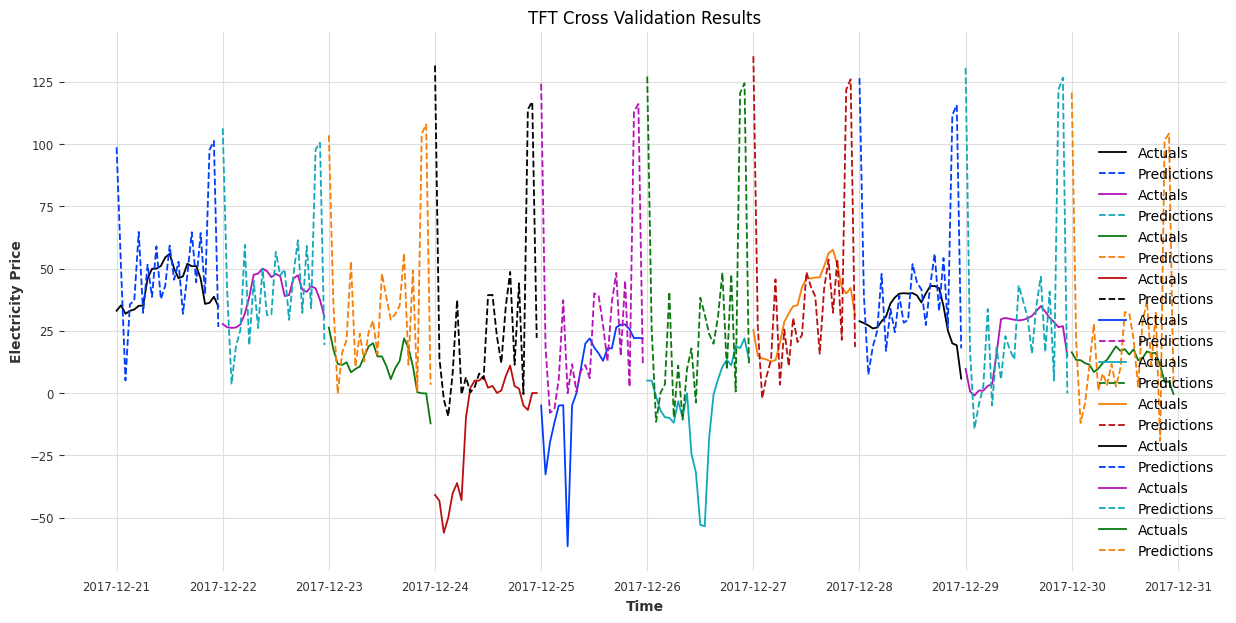

In [ ]:
fig,ax = plt.subplots(figsize=(15,7))

# Plot the actuals

for i in range(len(cv)):
  predictions = TimeSeries.to_series(scaler1.inverse_transform(cv[i]))

  # Determine date range for actuals
  start = predictions.index.min()
  end = predictions.index.max()
  actuals = df.y[start:end]

  ax.plot(actuals, label='Actuals')
  ax.plot(predictions, label='Predictions', linestyle='dashed')

  ax.set_xlabel('Time')
  ax.set_ylabel('Electricity Price')
  ax.set_title('TFT Cross Validation Results')
  ax.legend()

plt.show()

## Parameter Tuning

We will perform `ParameterSampler` tuning

In [ ]:
from sklearn.model_selection import ParameterSampler

# Parameter Grid

param_grid = {
    'input_chunk_length': [48,96, 172],
    'output_chunk_length': [24],
    'hidden_size': [8, 16, 24],
    'num_attention_heads': [2,4,6],
    'dropout': [0.1, 0.2, 0.3],
    'batch_size': [32, 64, 128],
    'lstm_layers': [1,2,4],
    'n_epochs': [5,10,20]
}

# Number of parameter combinations to try
n_iter=10

# Generate a list of parameter combinations to sample from the parameter grid
param_list = list(ParameterSampler(param_grid, n_iter=n_iter, random_state=42))

# Duplicate the parameter list for further use or comparison
param_list2 = param_list

# Print the list of parameter combinations
print(param_list)

[{'output_chunk_length': 24, 'num_attention_heads': 6, 'n_epochs': 10, 'lstm_layers': 4, 'input_chunk_length': 96, 'hidden_size': 16, 'dropout': 0.1, 'batch_size': 64}, {'output_chunk_length': 24, 'num_attention_heads': 4, 'n_epochs': 20, 'lstm_layers': 4, 'input_chunk_length': 172, 'hidden_size': 8, 'dropout': 0.3, 'batch_size': 64}, {'output_chunk_length': 24, 'num_attention_heads': 6, 'n_epochs': 10, 'lstm_layers': 4, 'input_chunk_length': 172, 'hidden_size': 16, 'dropout': 0.2, 'batch_size': 64}, {'output_chunk_length': 24, 'num_attention_heads': 2, 'n_epochs': 20, 'lstm_layers': 2, 'input_chunk_length': 96, 'hidden_size': 16, 'dropout': 0.2, 'batch_size': 64}, {'output_chunk_length': 24, 'num_attention_heads': 2, 'n_epochs': 5, 'lstm_layers': 4, 'input_chunk_length': 48, 'hidden_size': 24, 'dropout': 0.1, 'batch_size': 128}, {'output_chunk_length': 24, 'num_attention_heads': 2, 'n_epochs': 5, 'lstm_layers': 2, 'input_chunk_length': 172, 'hidden_size': 24, 'dropout': 0.3, 'batch_si

In [ ]:
# Define fixed parameters that will be used across all configurations

fixed_params = {
    'use_static_covariates': True,
    'add_encoders': add_encoders,
    'pl_trainer_kwargs': {'accelerator': 'gpu', "devices": [0]},
    }

# Update each parameter set in the list with the fixed parameters using the '.update()' function
for params in param_list:
  params.update(fixed_params)

In [ ]:
# Check the params list
param_list

[{'output_chunk_length': 24,
  'num_attention_heads': 6,
  'n_epochs': 10,
  'lstm_layers': 4,
  'input_chunk_length': 96,
  'hidden_size': 16,
  'dropout': 0.1,
  'batch_size': 64,
  'use_static_covariates': True,
  'add_encoders': {'cyclic': {'future': ['hour',
     'day',
     'dayofweek',
     'week',
     'month']},
   'datetime_attribute': {'future': ['hour',
     'day',
     'dayofweek',
     'week',
     'month']},
   'position': {'past': ['relative'], 'future': ['relative']},
   'custom': {'past': [<function __main__.encode_year(idx)>],
    'future': [<function __main__.encode_year(idx)>]},
   'transformer': Scaler,
   'tz': 'CET'},
  'pl_trainer_kwargs': {'accelerator': 'gpu', 'devices': [0]}},
 {'output_chunk_length': 24,
  'num_attention_heads': 4,
  'n_epochs': 20,
  'lstm_layers': 4,
  'input_chunk_length': 172,
  'hidden_size': 8,
  'dropout': 0.3,
  'batch_size': 64,
  'use_static_covariates': True,
  'add_encoders': {'cyclic': {'future': ['hour',
     'day',
     'dayo

In [ ]:
# Initialize a list to store RMSE values for each set of parameters
rmse = []

# Iterate over each set of parameter combinations
for params in param_list:
  # Build the TFT model using the current set of parameters
  model = TFTModel(**params)

  # Perform cross-validation with rolling forecast
  cv = model.historical_forecasts(
      series = y_transformed,
      past_covariates = past_covariates_transformed,
      future_covariates = future_covariates_transformed,
      forecast_horizon=forecast_horizon,  # Number of time steps to forecast
      start=df.shape[0] - 10 * forecast_horizon,  # Start point for the rolling forecast
      retrain=True,  # Whether to retrain the model at each step
      stride=forecast_horizon,  # Number of time steps to move forward for each forecast
      last_points_only=False  # Whether to include only the last points in each rolling window
  )

  # Initialize a list to store RMSE values for each fold
  rmse_cv = []

  # Iterate over each fold in the cross-validation results
  for i in range(len(cv)):
    # Get the predictions from the current fold and inverse transform to the original scale
    predictions = TimeSeries.to_series(scaler1.inverse_transform(cv[i]))

    # Extract the corresponding actual values
    start = predictions.index.min()
    end = predictions.index.max()
    actuals = df.y[start:end]

    # Compute the RMSE for the current fold
    error_cv = np.sqrt(mean_squared_error(actuals, predictions))
    rmse_cv.append(error_cv)

  # Compute the average RMSE for the current set of parameters and append to the list
  rmse.append(np.mean(rmse_cv))

  # Print the parameters tested and the corresponding RMSE
  print(f"Tested parameters: {params} => RMSE {np.mean(rmse_cv)}")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork      

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metric

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metric

...

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metric

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Tested parameters: {'output_chunk_length': 24, 'num_attention_heads': 2, 'n_epochs': 20, 'lstm_layers': 4, 'input_chunk_length': 48, 'hidden_size': 8, 'dropout': 0.1, 'batch_size': 128, 'use_static_covariates': True, 'add_encoders': {'cyclic': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'datetime_attribute': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'position': {'past': ['relative'], 'future': ['relative']}, 'custom': {'past': [<function encode_year at 0x79e0e94f1620>], 'future': [<function encode_year at 0x79e0e94f1620>]}, 'transformer': Scaler, 'tz': 'CET'}, 'pl_trainer_kwargs': {'accelerator': 'gpu', 'devices': [0]}} => RMSE 35.15231873279315


In [ ]:
# Create a DataFrame and add the RMSE values
results_df = pd.DataFrame(param_list2)
results_df['rmse'] = rmse
results_df

,output_chunk_length,num_attention_heads,n_epochs,lstm_layers,input_chunk_length,hidden_size,dropout,batch_size,use_static_covariates,add_encoders,pl_trainer_kwargs,rmse
0,24,6,10,4,96,16,0.1,64,True,"{'cyclic': {'future': ['hour', 'day', 'dayofwe...","{'accelerator': 'gpu', 'devices': [0]}",33.959321
1,24,4,20,4,172,8,0.3,64,True,"{'cyclic': {'future': ['hour', 'day', 'dayofwe...","{'accelerator': 'gpu', 'devices': [0]}",25.679161
2,24,6,10,4,172,16,0.2,64,True,"{'cyclic': {'future': ['hour', 'day', 'dayofwe...","{'accelerator': 'gpu', 'devices': [0]}",30.796029
3,24,2,20,2,96,16,0.2,64,True,"{'cyclic': {'future': ['hour', 'day', 'dayofwe...","{'accelerator': 'gpu', 'devices': [0]}",20.464998
4,24,2,5,4,48,24,0.1,128,True,"{'cyclic': {'future': ['hour', 'day', 'dayofwe...","{'accelerator': 'gpu', 'devices': [0]}",40.694776
5,24,2,5,2,172,24,0.3,128,True,"{'cyclic': {'future': ['hour', 'day', 'dayofwe...","{'accelerator': 'gpu', 'devices': [0]}",39.683951
6,24,4,20,1,172,24,0.2,32,True,"{'cyclic': {'future': ['hour', 'day', 'dayofwe...","{'accelerator': 'gpu', 'devices': [0]}",13.076245
7,24,6,10,4,48,8,0.3,64,True,"{'cyclic': {'future': ['hour', 'day', 'dayofwe...","{'accelerator': 'gpu', 'devices': [0]}",38.318101
8,24,2,20,1,48,16,0.2,32,True,"{'cyclic': {'future': ['hour', 'day', 'dayofwe...","{'accelerator': 'gpu', 'devices': [0]}",13.391366
9,24,2,20,4,48,8,0.1,128,True,"{'cyclic': {'future': ['hour', 'day', 'dayofwe...","{'accelerator': 'gpu', 'devices': [0]}",35.152319


In [ ]:
# Identify the parameter set(s) with the lowest RMSE and export it to a CSV file
best_params = results_df[results_df['rmse'] == results_df['rmse'].min()]
best_params.to_csv('best_params.csv')

## Predict the Future

In [ ]:
# Load the best parameters from the CSV file, and put it in a dictionary
best_params = pd.read_csv('best_params.csv', index_col =0).drop(columns = "rmse")
best_params_dict = best_params.squeeze().to_dict()
best_params_dict

{'output_chunk_length': 24,
 'num_attention_heads': 4,
 'n_epochs': 20,
 'lstm_layers': 1,
 'input_chunk_length': 172,
 'hidden_size': 24,
 'dropout': 0.2,
 'batch_size': 32,
 'use_static_covariates': True,
 'add_encoders': "{'cyclic': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'datetime_attribute': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'position': {'past': ['relative'], 'future': ['relative']}, 'custom': {'past': [<function encode_year at 0x79e0e94f1620>], 'future': [<function encode_year at 0x79e0e94f1620>]}, 'transformer': Scaler, 'tz': 'CET'}",
 'pl_trainer_kwargs': "{'accelerator': 'gpu', 'devices': [0]}"}

In [ ]:
# List of parameters that should be converted to integers
int_params = ['input_chunk_length', 'output_chunk_length',
              'hidden_size', 'num_attention_heads', 'batch_size',
              'lstm_layers', 'n_epochs']

# Convert specified float parameters to integers
for key in int_params:
  best_params_dict[key] = int(best_params_dict[key])

In [ ]:
# Update the best parameters dictionary with the fixed parameters
best_params_dict.update(fixed_params)
best_params_dict

{'output_chunk_length': 24,
 'num_attention_heads': 4,
 'n_epochs': 20,
 'lstm_layers': 1,
 'input_chunk_length': 172,
 'hidden_size': 24,
 'dropout': 0.2,
 'batch_size': 32,
 'use_static_covariates': True,
 'add_encoders': {'cyclic': {'future': ['hour',
    'day',
    'dayofweek',
    'week',
    'month']},
  'datetime_attribute': {'future': ['hour',
    'day',
    'dayofweek',
    'week',
    'month']},
  'position': {'past': ['relative'], 'future': ['relative']},
  'custom': {'past': [<function __main__.encode_year(idx)>],
   'future': [<function __main__.encode_year(idx)>]},
  'transformer': Scaler,
  'tz': 'CET'},
 'pl_trainer_kwargs': {'accelerator': 'gpu', 'devices': [0]}}

In [ ]:
# Build the TFT model using the best-tuned parameters
tuned_tft = TFTModel(**best_params_dict)

# Fit the tuned model
tuned_tft.fit(y_transformed,
                past_covariates = past_covariates_transformed,
                future_covariates = future_covariates_transformed)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork      

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


TFTModel(output_chunk_shift=0, hidden_size=24, lstm_layers=1, num_attention_heads=4, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.2, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=False, loss_fn=None, likelihood=None, norm_type=LayerNorm, use_static_covariates=True, output_chunk_length=24, n_epochs=20, input_chunk_length=172, batch_size=32, add_encoders={'cyclic': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'datetime_attribute': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'position': {'past': ['relative'], 'future': ['relative']}, 'custom': {'past': [<function encode_year at 0x79e0e94f1620>], 'future': [<function encode_year at 0x79e0e94f1620>]}, 'transformer': Scaler, 'tz': 'CET'}, pl_trainer_kwargs={'accelerator': 'gpu', 'devices': [0]})

In [ ]:
# Generate forecasts for the future using the tuned model
forecast = tuned_tft.predict(n = forecast_horizon,
                               series = y_transformed,
                               past_covariates = past_covariates_transformed,
                               future_covariates = future_covariates_transformed)

# Inverse transform the forecasted values to the original scale and rename the series
forecast = TimeSeries.to_series(scaler1.inverse_transform(forecast)).rename("TFT")
# Display the forecasted values
forecast

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

,TFT
ds,
2017-12-31 00:00:00,-19.959333
2017-12-31 01:00:00,-9.653243
2017-12-31 02:00:00,-11.274905
2017-12-31 03:00:00,-21.674125
2017-12-31 04:00:00,-14.795330
2017-12-31 05:00:00,-11.476848
2017-12-31 06:00:00,-30.255406
2017-12-31 07:00:00,-30.326666
2017-12-31 08:00:00,-20.526529


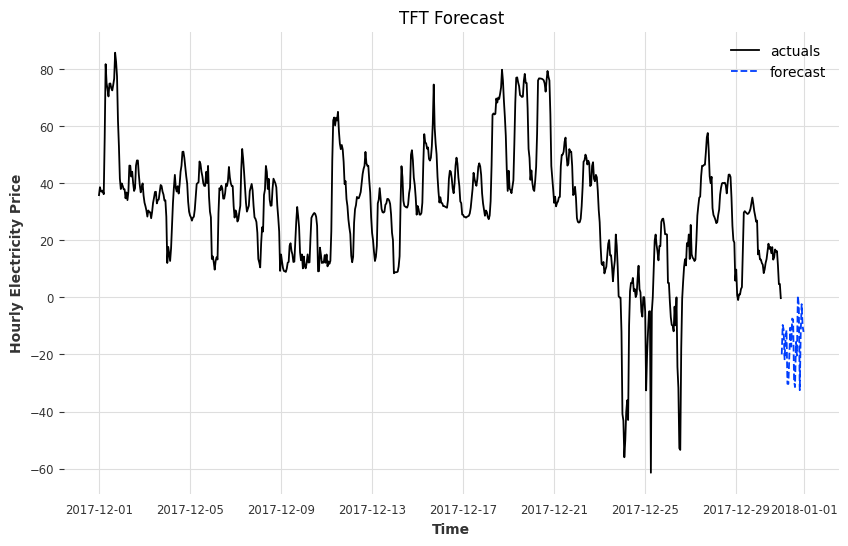

In [ ]:
# Plot the forecasted values along with actual data

# Set figure size
fig, ax = plt.subplots(figsize = (10,6))
# Plot actual values from December 2017 onwards
ax.plot(df.y['2017-12':], label = "actuals")
# Plot forecasted values with a dashed line
ax.plot(forecast, label = "forecast", linestyle = 'dashed')

# Set labels, title, and legend for the plot
ax.set_xlabel("Time")
ax.set_ylabel("Hourly Electricity Price")
ax.set_title("TFT Forecast")
ax.legend()
plt.show()

## Interpretability

In [ ]:
from darts.explainability import TFTExplainer

In [ ]:
# Build the explainer for the tuned TFT model
explainer = TFTExplainer(tuned_tft)
# Generate explainability results for the model
explainability_result = explainer.explain()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

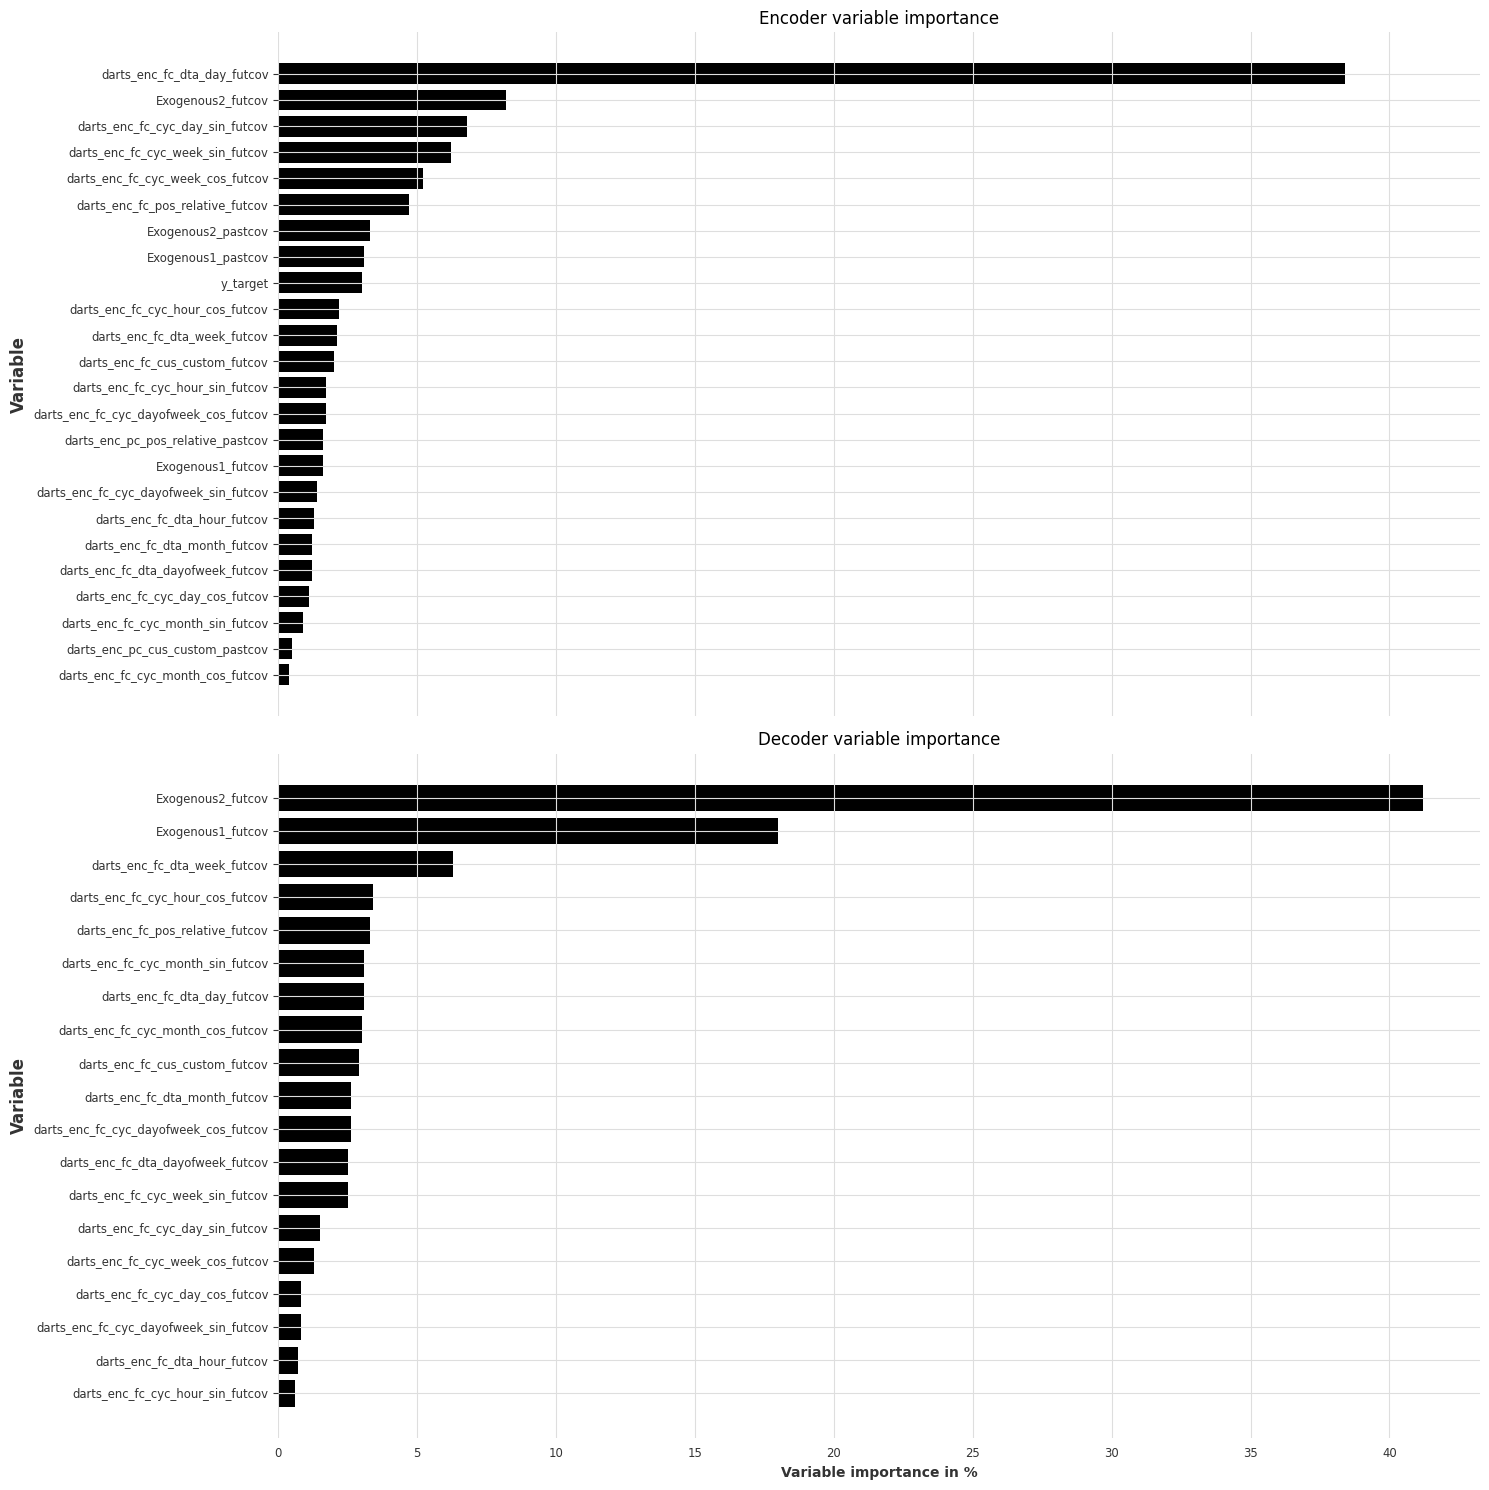

In [ ]:
# Plot the variable importance based on the explainability results
explainer.plot_variable_selection(explainability_result, fig_size = (15,15))

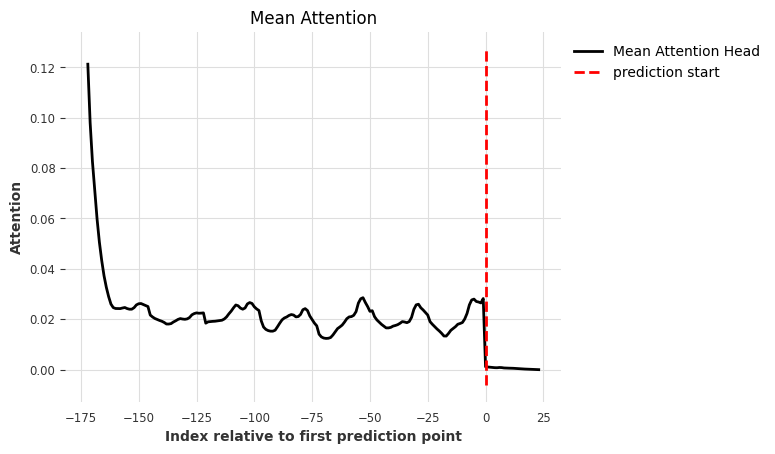

<Axes: title={'center': 'Mean Attention'}, xlabel='Index relative to first prediction point', ylabel='Attention'>

In [ ]:
# Plot the attention mechanism for the model
explainer.plot_attention(explainability_result, plot_type = "time")